<a href="https://colab.research.google.com/github/jlbs86/cutonala_24B_parallel_programming/blob/ezequiel_develop/Delaunay_Triangulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

In [25]:
# Generar puntos aleatorios
points = np.random.rand(10, 2)

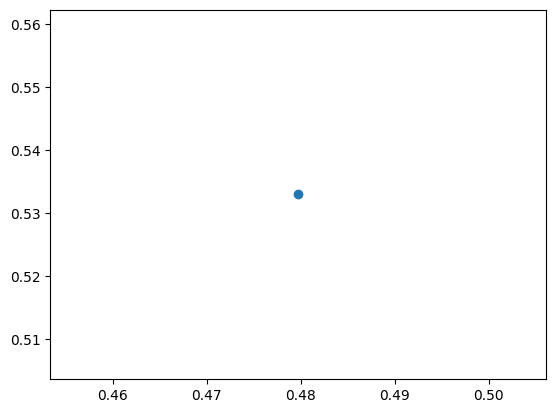

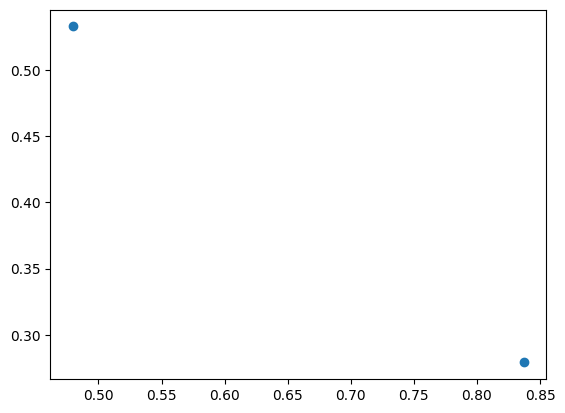

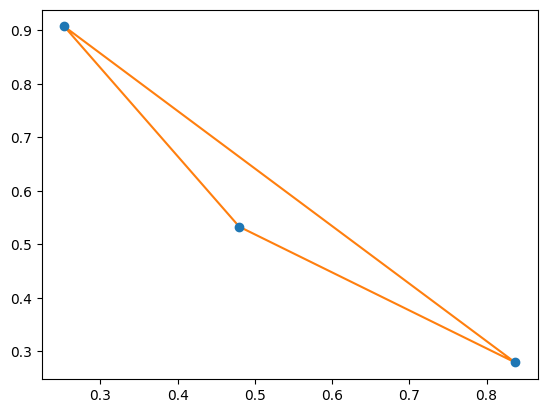

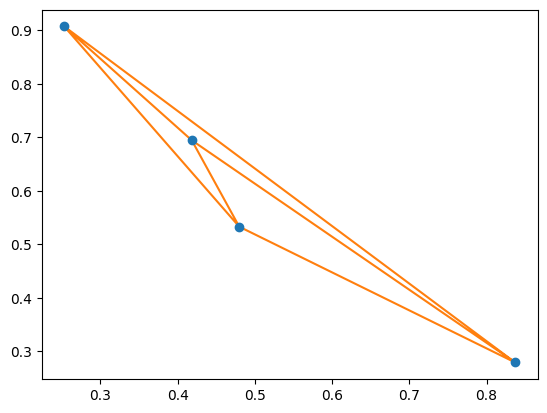

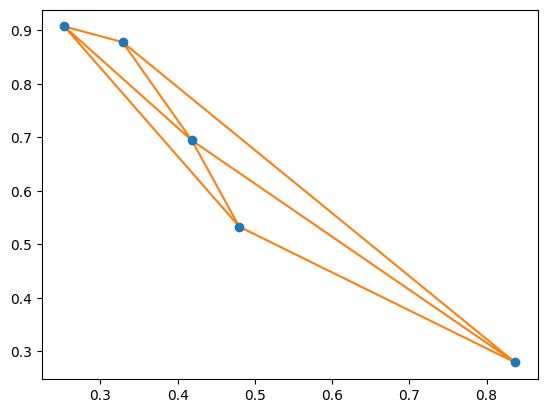

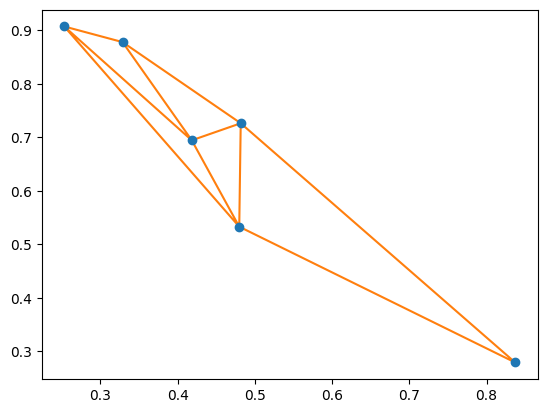

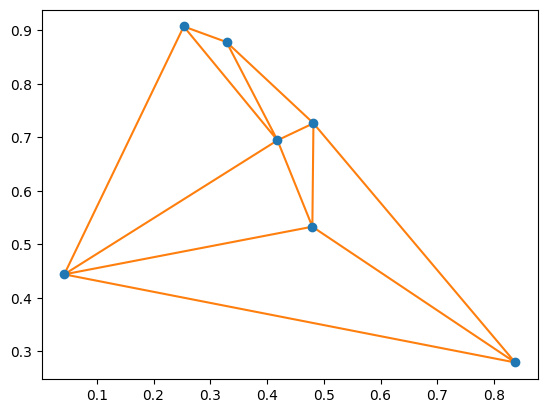

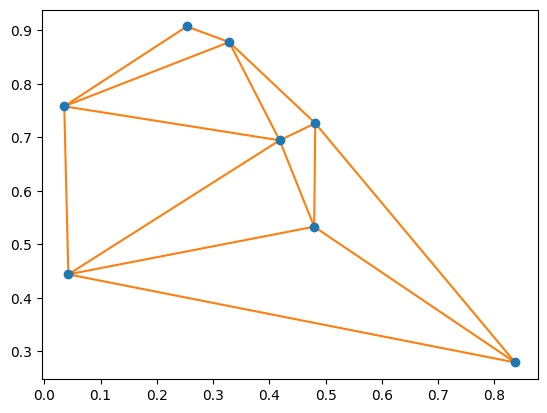

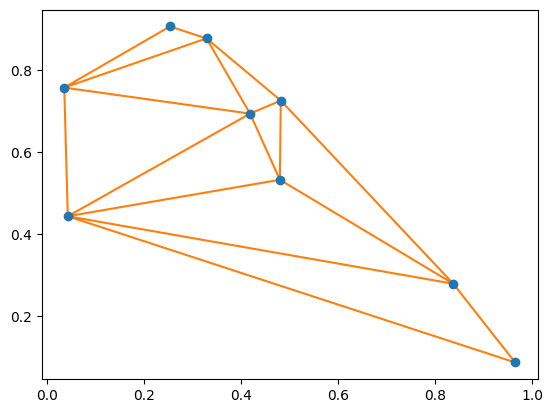

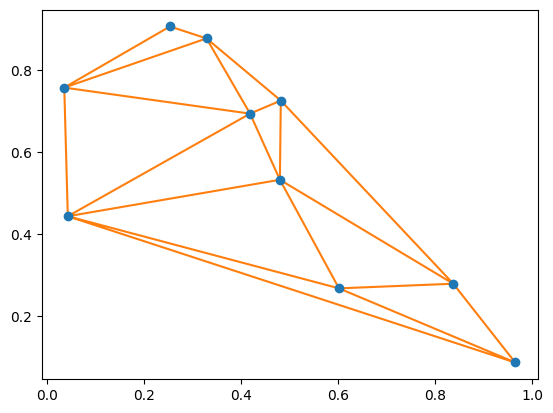

In [26]:
# Función para dibujar un círculo
def plot_circle(ax, center, radius):
    circle = plt.Circle(center, radius, color='r', fill=False, linestyle='dotted')
    ax.add_patch(circle)

# Crear una figura
fig, ax = plt.subplots()

# Agregar puntos uno por uno y actualizar la gráfica
for i in range(len(points)):
    plt.clf()  # Limpiar la figura
    plt.plot(points[:i+1, 0], points[:i+1, 1], 'o')  # Dibujar puntos
    if i >= 2:  # Necesitamos al menos 3 puntos para formar un triángulo
        tri = Delaunay(points[:i+1])
        plt.triplot(points[:i+1, 0], points[:i+1, 1], tri.simplices)  # Dibujar triangulación
        for simplex in tri.simplices:
            pts = points[simplex]
            A = np.linalg.norm(pts[1] - pts[0])
            B = np.linalg.norm(pts[2] - pts[0])
            C = np.linalg.norm(pts[2] - pts[1])
            s = (A + B + C) / 2
            area = np.sqrt(s * (s - A) * (s - B) * (s - C))
            radius = A * B * C / (4 * area)
            center = np.dot(np.linalg.inv(np.array([[pts[0][0], pts[0][1], 1], [pts[1][0], pts[1][1], 1], [pts[2][0], pts[2][1], 1]])), np.array([np.linalg.norm(pts[0])**2, np.linalg.norm(pts[1])**2, np.linalg.norm(pts[2])**2])) / (2 * area)
            plot_circle(ax, center[:2], radius)
    plt.pause(0.5)  # Pausa para visualizar el proceso

plt.show()

